# S5 Contrastive SSL Colab

This notebook builds a Colab-friendly S5 self-supervised learning baseline on Utah-array cache shards stored in Google Drive.

It supports two contrastive objectives behind one switch:

- `future_infonce`: CPC-style future-state InfoNCE over S5 hidden states.
- `augment_infonce`: same-window augmentation contrastive learning over pooled segment embeddings.

The notebook keeps the existing `s5_future_prediction.ipynb` data-loading pattern:

- mount Google Drive
- clone the public repo
- copy cache data to `/content`
- train from local disk
- save logs, checkpoints, and plots back to Drive


In [1]:
# Mount Drive and resolve cache / output roots.
from google.colab import drive
from pathlib import Path


drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive")
cache_candidates = [
    DRIVE_ROOT / "utah_ssl" / "data" / "cache_v1",
    DRIVE_ROOT / "utah_ssl" / "data" / "cache_v1_fused",
    DRIVE_ROOT / "utah_ssl" / "data" / "v1_cache",
    DRIVE_ROOT / "utah_ssl" / "data" / "v1_cache_fused",
    DRIVE_ROOT / "cache_v1",
    DRIVE_ROOT / "cache_v1_fused",
    DRIVE_ROOT / "v1_cache",
    DRIVE_ROOT / "v1_cache_fused",
]
CACHE_ROOT = next((p for p in cache_candidates if p.exists()), cache_candidates[0])
OUTPUT_ROOT = DRIVE_ROOT / "utah_ssl" / "outputs" / "ssl_experiments" / "contrastive"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("DRIVE_ROOT :", DRIVE_ROOT)
print("CACHE_ROOT :", CACHE_ROOT, "| exists:", CACHE_ROOT.exists())
print("OUTPUT_ROOT:", OUTPUT_ROOT, "| exists:", OUTPUT_ROOT.exists())

if CACHE_ROOT.exists():
    datasets = sorted(p.name for p in CACHE_ROOT.iterdir() if p.is_dir())
    print("datasets:", datasets)
else:
    print("cache candidates checked:")
    for path in cache_candidates:
        print(" -", path)


Mounted at /content/drive
DRIVE_ROOT : /content/drive/MyDrive
CACHE_ROOT : /content/drive/MyDrive/utah_ssl/data/cache_v1 | exists: True
OUTPUT_ROOT: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive | exists: True
datasets: ['000950', 'brain2text24', 'brain2text25', 'motor_data', 'plug_n_play', 'unsupervised_cursor_recalibration_offline', 'unsupervised_cursor_recalibration_online', 'willett_handwriting']


In [2]:
# Clone the public repo and import the reusable contrastive SSL helpers.
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/ethan-read/utah-ssl.git"
REPO_DIR = Path("/content/utah-ssl")
EXPERIMENTS_DIR = REPO_DIR / "analysis" / "active" / "ssl_experiments"
CONTRASTIVE_SSL_DIR = EXPERIMENTS_DIR / "contrastive_ssl"
SSL_DIR = REPO_DIR / "analysis" / "active" / "transfer_benchmark" / "ssl_autoresearch"

os.chdir("/content")

if REPO_DIR.exists():
    print("Using existing repo:", REPO_DIR)
else:
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

os.chdir(REPO_DIR)

for candidate in (REPO_DIR, EXPERIMENTS_DIR, SSL_DIR):
    candidate_str = str(candidate)
    if candidate_str not in sys.path:
        sys.path.insert(0, candidate_str)

os.environ["SSL_AUTORESEARCH_CACHE_ROOT"] = str(CACHE_ROOT)
os.environ["SSL_AUTORESEARCH_OUTPUT_ROOT"] = str(OUTPUT_ROOT)

if not CONTRASTIVE_SSL_DIR.exists():
    raise FileNotFoundError(
        "The cloned repo does not contain analysis/active/ssl_experiments/contrastive_ssl. "
        "If you are running this notebook from Colab, make sure REPO_DIR points at a repo checkout that includes the refactor."
    )

from contrastive_ssl import (
    CacheAccessConfig,
    DownstreamProbeConfig,
    SSLTrainingConfig,
    build_random_init_probe_state,
    build_segment_sampler,
    plot_ssl_training_history,
    prepare_cache_context,
    recover_downstream_probe_state,
    run_downstream_probe,
    run_probe_head_sweep,
    run_ssl_training,
)

try:
    from contrastive_ssl import list_ssl_checkpoints
except ImportError:
    from contrastive_ssl.training import list_ssl_checkpoints

print("cwd:", Path.cwd())
print("repo dir exists:", REPO_DIR.exists(), REPO_DIR)
print("experiments dir exists:", EXPERIMENTS_DIR.exists(), EXPERIMENTS_DIR)
print("contrastive_ssl dir exists:", CONTRASTIVE_SSL_DIR.exists(), CONTRASTIVE_SSL_DIR)
print("ssl dir exists:", SSL_DIR.exists(), SSL_DIR)
print("SSL_AUTORESEARCH_CACHE_ROOT:", os.environ["SSL_AUTORESEARCH_CACHE_ROOT"])
print("SSL_AUTORESEARCH_OUTPUT_ROOT:", os.environ["SSL_AUTORESEARCH_OUTPUT_ROOT"])


cwd: /content/utah-ssl
repo dir exists: True /content/utah-ssl
experiments dir exists: True /content/utah-ssl/analysis/active/ssl_experiments
contrastive_ssl dir exists: True /content/utah-ssl/analysis/active/ssl_experiments/contrastive_ssl
ssl dir exists: True /content/utah-ssl/analysis/active/transfer_benchmark/ssl_autoresearch
SSL_AUTORESEARCH_CACHE_ROOT: /content/drive/MyDrive/utah_ssl/data/cache_v1
SSL_AUTORESEARCH_OUTPUT_ROOT: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive


In [14]:
# Experiment config.
SEED = 7
OBJECTIVE_MODE = "future_infonce"
SEGMENT_BINS = 64
# With patch_size=4 and stride=2, horizon=6 starts the target patch strictly after the current patch.
FUTURE_HORIZONS = (6,)
PATCH_SIZE = 4
PATCH_STRIDE = 2
HIDDEN_SIZE = 256
S5_STATE_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.1
BATCH_SIZE = 32
NUM_STEPS = 1000
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-2
TEMPERATURE = 0.1
VAL_EVERY = 50
VAL_BATCHES = 10
CHECKPOINT_EVERY_STEPS = 100
DATASET_WEIGHT_ALPHA = 0.25
EXAMPLES_PER_SHARD = 8
POST_PROJ_NORM = "rms"
# CACHE_ACCESS_MODE = "copy_to_local"
CACHE_ACCESS_MODE = "drive_direct"

LOCAL_CACHE_BASE = "/content/utah_ssl_cache"
FORCE_RECOPY_LOCAL_CACHE = False
EXCLUDED_DATASETS = {"brain2text25"}
LOG_EVERY = 10
# Use a cheap cache-context normalization during setup, then swap in precomputed SSL session z-scoring below.
NORMALIZE_IMPL_VERSION = "session_featurewise_v1"
CACHE_PREPARE_NORMALIZE_IMPL_VERSION = "segment_prefix_v1"
NORMALIZE_CONTEXT_BINS = min(16, SEGMENT_BINS)  # Used only by the segment_prefix_v1 fallback.

AUGMENT_CFG = {
    "noise_std": 0.01,
    "scale_jitter": 0.05,
    "offset_jitter": 0.05,
    "time_mask_frac": 0.10,
    "channel_dropout_prob": 0.05,
    "clip_value": 20.0,
}

CACHE_ACCESS_CONFIG = CacheAccessConfig(
    mode=CACHE_ACCESS_MODE,
    local_cache_base=LOCAL_CACHE_BASE,
    force_recopy_local_cache=FORCE_RECOPY_LOCAL_CACHE,
    excluded_datasets=tuple(sorted(EXCLUDED_DATASETS)),
    seed=SEED,
    segment_bins=SEGMENT_BINS,
    normalize_context_bins=NORMALIZE_CONTEXT_BINS,
    normalize_impl_version=CACHE_PREPARE_NORMALIZE_IMPL_VERSION,
    examples_per_shard=EXAMPLES_PER_SHARD,
)
SSL_TRAINING_CONFIG = SSLTrainingConfig(
    seed=SEED,
    objective_mode=OBJECTIVE_MODE,
    segment_bins=SEGMENT_BINS,
    future_horizons=FUTURE_HORIZONS,
    patch_size=PATCH_SIZE,
    patch_stride=PATCH_STRIDE,
    hidden_size=HIDDEN_SIZE,
    s5_state_size=S5_STATE_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    batch_size=BATCH_SIZE,
    num_steps=NUM_STEPS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    temperature=TEMPERATURE,
    val_every=VAL_EVERY,
    val_batches=VAL_BATCHES,
    checkpoint_every_steps=CHECKPOINT_EVERY_STEPS,
    dataset_weight_alpha=DATASET_WEIGHT_ALPHA,
    examples_per_shard=EXAMPLES_PER_SHARD,
    log_every=LOG_EVERY,
    post_proj_norm=POST_PROJ_NORM,
    augment_cfg=dict(AUGMENT_CFG),
)

print("SSL patch config:", {
    "patch_size": PATCH_SIZE,
    "patch_stride": PATCH_STRIDE,
    "future_horizons": FUTURE_HORIZONS,
})
print("SSL checkpoint cadence:", CHECKPOINT_EVERY_STEPS)
print("SSL normalization config:", {
    "ssl_normalize_impl_version": NORMALIZE_IMPL_VERSION,
    "prepare_cache_normalize_impl_version": CACHE_PREPARE_NORMALIZE_IMPL_VERSION,
    "normalize_context_bins_fallback": NORMALIZE_CONTEXT_BINS,
})
print("CACHE_ACCESS_CONFIG:", CACHE_ACCESS_CONFIG)
print("SSL_TRAINING_CONFIG:", SSL_TRAINING_CONFIG)


SSL patch config: {'patch_size': 4, 'patch_stride': 2, 'future_horizons': (6,)}
SSL checkpoint cadence: 100
SSL normalization config: {'ssl_normalize_impl_version': 'session_featurewise_v1', 'prepare_cache_normalize_impl_version': 'segment_prefix_v1', 'normalize_context_bins_fallback': 16}
CACHE_ACCESS_CONFIG: CacheAccessConfig(mode='drive_direct', local_cache_base='/content/utah_ssl_cache', force_recopy_local_cache=False, excluded_datasets=('brain2text25',), seed=7, segment_bins=64, normalize_context_bins=16, normalize_impl_version='segment_prefix_v1', examples_per_shard=8, tx_dim=256, sbp_dim=256, shard_cache_ram_gb=None)
SSL_TRAINING_CONFIG: SSLTrainingConfig(seed=7, objective_mode='future_infonce', segment_bins=64, future_horizons=(6,), patch_size=4, patch_stride=2, hidden_size=256, s5_state_size=128, num_layers=2, dropout=0.1, batch_size=32, num_steps=1000, learning_rate=0.0003, weight_decay=0.01, temperature=0.1, val_every=50, val_batches=10, checkpoint_every_steps=100, dataset_w

In [15]:
# Resolve cache access mode, summarize datasets, and build the reusable cache context.
import os

CACHE_CONTEXT = prepare_cache_context(
    cache_candidates=cache_candidates,
    config=CACHE_ACCESS_CONFIG,
)

DRIVE_CACHE_ROOT = CACHE_CONTEXT.drive_cache_root
CACHE_ROOT = CACHE_CONTEXT.cache_root
ACTIVE_CACHE_ROOT = CACHE_CONTEXT.cache_root
CACHE_COPY_USED = CACHE_CONTEXT.cache_copy_used
SOURCE_CACHE_SIGNATURE = CACHE_CONTEXT.source_cache_signature
available_datasets = CACHE_CONTEXT.available_datasets
pretrain_datasets = CACHE_CONTEXT.pretrain_datasets
session_split_summary = CACHE_CONTEXT.session_split_summary
SHARD_STORE = CACHE_CONTEXT.shard_store
SHARD_CACHE_RAM_GB = SHARD_STORE.summary()["budget_gb"]
HAS_VAL_DATASETS = CACHE_CONTEXT.has_val_datasets
TX_DIM = CACHE_CONTEXT.tx_dim
SBP_DIM = CACHE_CONTEXT.sbp_dim
FULL_DIM = CACHE_CONTEXT.full_dim
CACHE_CONTEXT_NORMALIZE_IMPL_VERSION = CACHE_CONTEXT.normalize_impl_version
NORMALIZE_CONTEXT_BINS = CACHE_CONTEXT.normalize_context_bins
SSL_SESSION_STATS_COUNT = len(CACHE_CONTEXT.session_feature_stats)

os.environ["SSL_AUTORESEARCH_CACHE_ROOT"] = str(CACHE_ROOT)

print("CACHE_ACCESS_MODE:", CACHE_ACCESS_CONFIG.mode)
print("CACHE_COPY_USED:", CACHE_COPY_USED)
print("ACTIVE_CACHE_ROOT:", CACHE_ROOT)
print("CACHE_CONTEXT_NORMALIZE_IMPL_VERSION (before SSL stats load):", CACHE_CONTEXT_NORMALIZE_IMPL_VERSION)
print("TARGET_SSL_NORMALIZE_IMPL_VERSION:", NORMALIZE_IMPL_VERSION)
print("NORMALIZE_CONTEXT_BINS (fallback only):", NORMALIZE_CONTEXT_BINS)
print("SSL_SESSION_STATS_COUNT:", SSL_SESSION_STATS_COUNT)
print("SHARD_CACHE_RAM_GB:", SHARD_CACHE_RAM_GB)
print("available datasets:")
for name in available_datasets:
    tag = "excluded" if name in EXCLUDED_DATASETS else "included"
    print(f" - {name} [{tag}]")
print("session split summary:")
for dataset in pretrain_datasets:
    summary = session_split_summary[dataset]
    print(
        f" - {dataset}: sessions={summary['total_sessions']} train_sessions={summary['train_sessions']} "
        f"val_sessions={summary['val_sessions']} train_examples={summary['train_examples']} "
        f"val_examples={summary['val_examples']} val_eligible={summary['val_eligible']}"
    )
print("shard cache:", SHARD_STORE.summary())


using Drive-backed cache directly; skipping local copy
source: /content/drive/MyDrive/utah_ssl/data/cache_v1
source signature: 9cdbfaa6cf55
CACHE_ACCESS_MODE: drive_direct
CACHE_COPY_USED: False
ACTIVE_CACHE_ROOT: /content/drive/MyDrive/utah_ssl/data/cache_v1
CACHE_CONTEXT_NORMALIZE_IMPL_VERSION (before SSL stats load): segment_prefix_v1
TARGET_SSL_NORMALIZE_IMPL_VERSION: session_featurewise_v1
NORMALIZE_CONTEXT_BINS (fallback only): 16
SSL_SESSION_STATS_COUNT: 0
SHARD_CACHE_RAM_GB: 8.0
available datasets:
 - 000950 [included]
 - brain2text24 [included]
 - brain2text25 [excluded]
 - motor_data [included]
 - plug_n_play [included]
 - unsupervised_cursor_recalibration_offline [included]
 - unsupervised_cursor_recalibration_online [included]
 - willett_handwriting [included]
session split summary:
 - 000950: sessions=47 train_sessions=37 val_sessions=10 train_examples=569 val_examples=159 val_eligible=True
 - brain2text24: sessions=28 train_sessions=22 val_sessions=6 train_examples=12811 

In [19]:
# Compute or load SSL session-level featurewise z-scoring stats for pretraining.
import random
import time
from collections import defaultdict
from pathlib import Path

import numpy as np
import torch

SESSION_STATS_REFERENCE_DATASET = "000950"
SESSION_STATS_REFERENCE_MULTIPLIER = 2
SESSION_STATS_OUTPUT_DIR = OUTPUT_ROOT / "precomputed_ssl_session_stats"
SESSION_STATS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def stable_text_seed(text: str, base_seed: int) -> int:
    return int(base_seed + sum((idx + 1) * ord(ch) for idx, ch in enumerate(text)))


def session_key_for(dataset: str, session_id: str) -> str:
    return f"{dataset}:{session_id}"


def sample_rows_up_to_bins(rows, *, cap_bins: int, seed: int):
    total_bins = int(sum(int(row.n_time_bins) for row in rows))
    if total_bins <= int(cap_bins):
        return list(rows), total_bins, False

    rng = random.Random(int(seed))
    shuffled = list(rows)
    rng.shuffle(shuffled)

    selected = []
    selected_bins = 0
    for row in shuffled:
        row_bins = int(row.n_time_bins)
        if selected and selected_bins >= int(cap_bins):
            break
        if (selected_bins + row_bins) <= int(cap_bins) or not selected:
            selected.append(row)
            selected_bins += row_bins
    return selected, selected_bins, True


def compute_feature_stats_for_rows(rows):
    sum_x = np.zeros((FULL_DIM,), dtype=np.float64)
    sum_x2 = np.zeros((FULL_DIM,), dtype=np.float64)
    count_x = np.zeros((FULL_DIM,), dtype=np.float64)

    for row in rows:
        shard = SHARD_STORE.get(row.shard_relpath)
        time_offsets = shard["time_offsets"]
        assert isinstance(time_offsets, np.ndarray)
        start = int(time_offsets[row.example_index])
        stop = int(time_offsets[row.example_index + 1])

        tx = shard["tx"]
        if isinstance(tx, np.ndarray):
            tx_window = np.asarray(tx[start:stop], dtype=np.float64)
            tx_dim = min(tx_window.shape[1], TX_DIM)
            sum_x[:tx_dim] += tx_window[:, :tx_dim].sum(axis=0)
            sum_x2[:tx_dim] += np.square(tx_window[:, :tx_dim]).sum(axis=0)
            count_x[:tx_dim] += tx_window.shape[0]

        sbp = shard["sbp"]
        if isinstance(sbp, np.ndarray):
            sbp_window = np.asarray(sbp[start:stop], dtype=np.float64)
            sbp_dim = min(sbp_window.shape[1], SBP_DIM)
            sbp_slice = slice(TX_DIM, TX_DIM + sbp_dim)
            sum_x[sbp_slice] += sbp_window[:, :sbp_dim].sum(axis=0)
            sum_x2[sbp_slice] += np.square(sbp_window[:, :sbp_dim]).sum(axis=0)
            count_x[sbp_slice] += sbp_window.shape[0]

    mean = np.zeros((FULL_DIM,), dtype=np.float32)
    std = np.ones((FULL_DIM,), dtype=np.float32)
    present_mask = count_x > 0
    if present_mask.any():
        mean64 = sum_x[present_mask] / count_x[present_mask]
        var64 = np.maximum(sum_x2[present_mask] / count_x[present_mask] - np.square(mean64), 1e-6)
        mean[present_mask] = mean64.astype(np.float32)
        std[present_mask] = np.sqrt(var64).astype(np.float32)
    return torch.from_numpy(mean), torch.from_numpy(std)


session_rows_by_key = defaultdict(list)
session_order_by_dataset = defaultdict(list)
for dataset in pretrain_datasets:
    seen_session_ids = set()
    for row in CACHE_CONTEXT.rows_by_dataset[dataset]:
        session_rows_by_key[session_key_for(dataset, row.session_id)].append(row)
        if row.session_id not in seen_session_ids:
            session_order_by_dataset[dataset].append(row.session_id)
            seen_session_ids.add(row.session_id)

session_bins_by_key = {
    key: int(sum(int(row.n_time_bins) for row in rows))
    for key, rows in session_rows_by_key.items()
}
reference_session_ids = session_order_by_dataset.get(SESSION_STATS_REFERENCE_DATASET, [])
if not reference_session_ids:
    raise ValueError(
        f"Could not find any pretraining sessions in dataset={SESSION_STATS_REFERENCE_DATASET} to set the sampling cap."
    )

REFERENCE_SESSION_ID = reference_session_ids[0]
REFERENCE_SESSION_KEY = session_key_for(SESSION_STATS_REFERENCE_DATASET, REFERENCE_SESSION_ID)
REFERENCE_SESSION_BINS = int(session_bins_by_key[REFERENCE_SESSION_KEY])
SESSION_STATS_CAP_BINS = int(SESSION_STATS_REFERENCE_MULTIPLIER * REFERENCE_SESSION_BINS)
SSL_SESSION_STATS_PATH = SESSION_STATS_OUTPUT_DIR / (
    f"session_feature_stats_{SOURCE_CACHE_SIGNATURE[:12]}_"
    f"{NORMALIZE_IMPL_VERSION}_refds{SESSION_STATS_REFERENCE_DATASET}_"
    f"cap{SESSION_STATS_CAP_BINS}_tx{TX_DIM}_sbp{SBP_DIM}.pt"
)

print("REFERENCE_DATASET:", SESSION_STATS_REFERENCE_DATASET)
print("REFERENCE_SESSION_ID:", REFERENCE_SESSION_ID)
print("REFERENCE_SESSION_KEY:", REFERENCE_SESSION_KEY)
print("REFERENCE_SESSION_BINS:", REFERENCE_SESSION_BINS)
print("SESSION_STATS_CAP_BINS:", SESSION_STATS_CAP_BINS)
print("SSL_SESSION_STATS_PATH:", SSL_SESSION_STATS_PATH)

if SSL_SESSION_STATS_PATH.exists():
    payload = torch.load(SSL_SESSION_STATS_PATH, map_location="cpu")
    SSL_SESSION_FEATURE_STATS = {
        str(key): (value[0].float().cpu(), value[1].float().cpu())
        for key, value in payload["session_feature_stats"].items()
    }
    SSL_SESSION_STATS_METADATA = dict(payload.get("metadata", {}))
    print("Loaded cached SSL session stats from disk.")
else:
    SSL_SESSION_FEATURE_STATS = {}
    sampling_summary = {}
    total_sessions = len(session_rows_by_key)
    truncated_sessions = 0
    t0 = time.time()

    for session_idx, session_key in enumerate(sorted(session_rows_by_key), start=1):
        rows = session_rows_by_key[session_key]
        sampled_rows, sampled_bins, was_truncated = sample_rows_up_to_bins(
            rows,
            cap_bins=SESSION_STATS_CAP_BINS,
            seed=stable_text_seed(session_key, SEED),
        )
        if was_truncated:
            truncated_sessions += 1
        SSL_SESSION_FEATURE_STATS[session_key] = compute_feature_stats_for_rows(sampled_rows)
        sampling_summary[session_key] = {
            "full_session_bins": int(session_bins_by_key[session_key]),
            "sampled_bins": int(sampled_bins),
            "full_example_count": int(len(rows)),
            "sampled_example_count": int(len(sampled_rows)),
            "truncated": bool(was_truncated),
        }
        if session_idx == 1 or session_idx % 25 == 0 or session_idx == total_sessions:
            print(
                f"session_stats={session_idx}/{total_sessions} key={session_key} "
                f"bins={sampled_bins}/{session_bins_by_key[session_key]} truncated={was_truncated}"
            )

    SSL_SESSION_STATS_METADATA = {
        "source_cache_signature": SOURCE_CACHE_SIGNATURE,
        "normalize_impl_version": NORMALIZE_IMPL_VERSION,
        "reference_dataset": SESSION_STATS_REFERENCE_DATASET,
        "reference_session_id": REFERENCE_SESSION_ID,
        "reference_session_key": REFERENCE_SESSION_KEY,
        "reference_session_bins": int(REFERENCE_SESSION_BINS),
        "session_stats_cap_bins": int(SESSION_STATS_CAP_BINS),
        "session_count": int(len(SSL_SESSION_FEATURE_STATS)),
        "truncated_sessions": int(truncated_sessions),
        "tx_dim": int(TX_DIM),
        "sbp_dim": int(SBP_DIM),
        "seed": int(SEED),
        "cache_root": str(CACHE_ROOT),
        "written_seconds": float(time.time()),
        "sampling_summary": sampling_summary,
    }
    torch.save(
        {
            "metadata": SSL_SESSION_STATS_METADATA,
            "session_feature_stats": SSL_SESSION_FEATURE_STATS,
        },
        SSL_SESSION_STATS_PATH,
    )
    print(f"Saved cached SSL session stats in {time.time() - t0:.1f}s")

CACHE_CONTEXT.session_feature_stats = dict(SSL_SESSION_FEATURE_STATS)
CACHE_CONTEXT.config.normalize_impl_version = NORMALIZE_IMPL_VERSION
CACHE_CONTEXT_NORMALIZE_IMPL_VERSION = CACHE_CONTEXT.normalize_impl_version
SSL_SESSION_STATS_COUNT = len(CACHE_CONTEXT.session_feature_stats)

print("CACHE_CONTEXT_NORMALIZE_IMPL_VERSION (after SSL stats load):", CACHE_CONTEXT_NORMALIZE_IMPL_VERSION)
print("SSL_SESSION_STATS_COUNT:", SSL_SESSION_STATS_COUNT)
print(
    "SSL session stats metadata:",
    {
        "reference_dataset": SSL_SESSION_STATS_METADATA.get("reference_dataset"),
        "reference_session_key": SSL_SESSION_STATS_METADATA.get("reference_session_key"),
        "reference_session_bins": SSL_SESSION_STATS_METADATA.get("reference_session_bins"),
        "session_stats_cap_bins": SSL_SESSION_STATS_METADATA.get("session_stats_cap_bins"),
        "truncated_sessions": SSL_SESSION_STATS_METADATA.get("truncated_sessions"),
    },
)


REFERENCE_DATASET: 000950
REFERENCE_SESSION_ID: sub-T5-held-in-calib_ses-20220518
REFERENCE_SESSION_KEY: 000950:sub-T5-held-in-calib_ses-20220518
REFERENCE_SESSION_BINS: 63341
SESSION_STATS_CAP_BINS: 126682
SSL_SESSION_STATS_PATH: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/precomputed_ssl_session_stats/session_feature_stats_9cdbfaa6cf55_session_featurewise_v1_refds000950_cap126682_tx256_sbp256.pt
session_stats=1/251 key=000950:sub-T5-held-in-calib_ses-20220518 bins=63341/63341 truncated=False
session_stats=25/251 key=000950:sub-T5-held-in-minival_ses-20220601 bins=3036/3036 truncated=False
session_stats=50/251 key=brain2text24:t12.2022.04.28 bins=126675/170161 truncated=True
session_stats=75/251 key=brain2text24:t12.2022.08.25 bins=126655/183534 truncated=True
session_stats=100/251 key=plug_n_play:t5.2022.06.01__seed_model_training bins=126357/188373 truncated=True
session_stats=125/251 key=plug_n_play:t5.2022.12.15__recalibration bins=39648/39648 truncated=Fal

In [21]:
# Load precomputed SSL session-level featurewise z-scoring stats from a stable Drive path.
from pathlib import Path
import torch

STABLE_SSL_SESSION_STATS_PATH = Path(
    "/content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/precomputed_ssl_session_stats/"
    "session_feature_stats_session_featurewise_v1_refds000950_cap126682_tx256_sbp256_stable.pt"
)

if not STABLE_SSL_SESSION_STATS_PATH.exists():
    raise FileNotFoundError(
        f"Stable SSL session stats file not found: {STABLE_SSL_SESSION_STATS_PATH}\n"
        "Run the one-time copy cell first."
    )

payload = torch.load(STABLE_SSL_SESSION_STATS_PATH, map_location="cpu")

SSL_SESSION_FEATURE_STATS = {
    str(key): (value[0].float().cpu(), value[1].float().cpu())
    for key, value in payload["session_feature_stats"].items()
}
SSL_SESSION_STATS_METADATA = dict(payload.get("metadata", {}))
SSL_SESSION_STATS_PATH = STABLE_SSL_SESSION_STATS_PATH

CACHE_CONTEXT.session_feature_stats = dict(SSL_SESSION_FEATURE_STATS)
CACHE_CONTEXT.config.normalize_impl_version = NORMALIZE_IMPL_VERSION
CACHE_CONTEXT_NORMALIZE_IMPL_VERSION = CACHE_CONTEXT.normalize_impl_version
SSL_SESSION_STATS_COUNT = len(CACHE_CONTEXT.session_feature_stats)

print("Loaded cached SSL session stats from stable path.")
print("SSL_SESSION_STATS_PATH:", SSL_SESSION_STATS_PATH)
print("CACHE_CONTEXT_NORMALIZE_IMPL_VERSION:", CACHE_CONTEXT_NORMALIZE_IMPL_VERSION)
print("SSL_SESSION_STATS_COUNT:", SSL_SESSION_STATS_COUNT)
print(
    "SSL session stats metadata:",
    {
        "reference_dataset": SSL_SESSION_STATS_METADATA.get("reference_dataset"),
        "reference_session_key": SSL_SESSION_STATS_METADATA.get("reference_session_key"),
        "reference_session_bins": SSL_SESSION_STATS_METADATA.get("reference_session_bins"),
        "session_stats_cap_bins": SSL_SESSION_STATS_METADATA.get("session_stats_cap_bins"),
        "truncated_sessions": SSL_SESSION_STATS_METADATA.get("truncated_sessions"),
    },
)


Loaded cached SSL session stats from stable path.
SSL_SESSION_STATS_PATH: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/precomputed_ssl_session_stats/session_feature_stats_session_featurewise_v1_refds000950_cap126682_tx256_sbp256_stable.pt
CACHE_CONTEXT_NORMALIZE_IMPL_VERSION: session_featurewise_v1
SSL_SESSION_STATS_COUNT: 251
SSL session stats metadata: {'reference_dataset': '000950', 'reference_session_key': '000950:sub-T5-held-in-calib_ses-20220518', 'reference_session_bins': 63341, 'session_stats_cap_bins': 126682, 'truncated_sessions': 70}


In [16]:
# Sampler smoke test.
from collections import Counter

INSPECT_BATCH_SIZE = 8
inspect_train_sampler = build_segment_sampler(
    CACHE_CONTEXT,
    "train",
    batch_size=INSPECT_BATCH_SIZE,
    seed=SEED,
    segment_bins=SEGMENT_BINS,
    dataset_weight_alpha=DATASET_WEIGHT_ALPHA,
    examples_per_shard=EXAMPLES_PER_SHARD,
)
inspect_batch = inspect_train_sampler.sample_batch()

print("train batch shapes:")
print(" - x           :", tuple(inspect_batch["x"].shape))
print(" - feature_mask:", tuple(inspect_batch["feature_mask"].shape))
print(" - lengths     :", tuple(inspect_batch["lengths"].shape))
print(" - dataset mix :", Counter(inspect_batch["datasets"]))
print(" - session keys:", inspect_batch["session_keys"][:3])

if HAS_VAL_DATASETS:
    inspect_val_sampler = build_segment_sampler(
        CACHE_CONTEXT,
        "val",
        batch_size=min(INSPECT_BATCH_SIZE, 4),
        seed=SEED + 1,
        segment_bins=SEGMENT_BINS,
        dataset_weight_alpha=DATASET_WEIGHT_ALPHA,
        examples_per_shard=EXAMPLES_PER_SHARD,
    )
    inspect_val_batch = inspect_val_sampler.sample_batch()
    print("\nval batch shapes:")
    print(" - x           :", tuple(inspect_val_batch["x"].shape))
    print(" - feature_mask:", tuple(inspect_val_batch["feature_mask"].shape))
    print(" - lengths     :", tuple(inspect_val_batch["lengths"].shape))
    print(" - dataset mix :", Counter(inspect_val_batch["datasets"]))
else:
    print("\nNo validation sampler was built because all datasets are single-session.")


train batch shapes:
 - x           : (8, 64, 512)
 - feature_mask: (8, 512)
 - lengths     : (8,)
 - dataset mix : Counter({'willett_handwriting': 2, 'unsupervised_cursor_recalibration_online': 2, '000950': 1, 'unsupervised_cursor_recalibration_offline': 1, 'motor_data': 1, 'brain2text24': 1})
 - session keys: ['000950:sub-T5-held-in-calib_ses-20220525', 'unsupervised_cursor_recalibration_offline:t5.2019.04.01', 'willett_handwriting:t5.2019.05.08']

val batch shapes:
 - x           : (4, 64, 512)
 - feature_mask: (4, 512)
 - lengths     : (4,)
 - dataset mix : Counter({'motor_data': 2, 'willett_handwriting': 1, 'unsupervised_cursor_recalibration_online': 1})


In [17]:
# Runtime summary.
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
print("FULL_DIM:", FULL_DIM)
print("pretrain_datasets:", pretrain_datasets)
print("HAS_VAL_DATASETS:", HAS_VAL_DATASETS)
print("CACHE_CONTEXT_NORMALIZE_IMPL_VERSION:", CACHE_CONTEXT.normalize_impl_version)
print("SSL_SESSION_STATS_COUNT:", len(CACHE_CONTEXT.session_feature_stats))
if "SSL_SESSION_STATS_PATH" in globals():
    print("SSL_SESSION_STATS_PATH:", SSL_SESSION_STATS_PATH)


DEVICE: cuda
FULL_DIM: 512
pretrain_datasets: ['000950', 'brain2text24', 'motor_data', 'plug_n_play', 'unsupervised_cursor_recalibration_offline', 'unsupervised_cursor_recalibration_online', 'willett_handwriting']
HAS_VAL_DATASETS: True
CACHE_CONTEXT_NORMALIZE_IMPL_VERSION: segment_prefix_v1
SSL_SESSION_STATS_COUNT: 0


In [6]:
# Optional: recover the latest saved SSL checkpoint instead of starting a fresh run.
# Set SSL_RECOVERY_EXPLICIT_CHECKPOINT_PATH to load a specific step/final checkpoint.
import json
from pathlib import Path

from contrastive_ssl.model import ContrastiveSSLModel

SSL_RECOVERY_EXPLICIT_CHECKPOINT_PATH = None
SSL_RECOVERY_RUN_DIR = None


def _recover_ssl_checkpoint_path():
    if SSL_RECOVERY_EXPLICIT_CHECKPOINT_PATH is not None:
        return Path(SSL_RECOVERY_EXPLICIT_CHECKPOINT_PATH)

    candidate_run_dir = None
    if SSL_RECOVERY_RUN_DIR is not None:
        candidate_run_dir = Path(SSL_RECOVERY_RUN_DIR)
    elif "run_dir" in globals() and run_dir is not None and Path(run_dir).exists():
        candidate_run_dir = Path(run_dir)
    else:
        available_run_dirs = sorted(
            [path for path in Path(OUTPUT_ROOT).glob("colab_s5_*") if path.is_dir()],
            key=lambda path: path.stat().st_mtime,
        )
        if available_run_dirs:
            candidate_run_dir = available_run_dirs[-1]

    if candidate_run_dir is None:
        raise RuntimeError(
            f"Could not find an SSL run directory under {OUTPUT_ROOT}. "
            "Set SSL_RECOVERY_EXPLICIT_CHECKPOINT_PATH or SSL_RECOVERY_RUN_DIR first."
        )

    available_checkpoints = [
        row for row in list_ssl_checkpoints(candidate_run_dir) if not row.get("load_error")
    ]
    if not available_checkpoints:
        raise RuntimeError(
            f"No readable SSL checkpoints were found in {candidate_run_dir}. "
            "If training was interrupted before the first save, there may be nothing to recover yet."
        )

    selected = sorted(
        available_checkpoints,
        key=lambda row: (int(row.get("step", -1)), row.get("kind") == "final"),
    )[-1]
    return Path(selected["path"])


def _recover_ssl_run_state_from_checkpoint(checkpoint_path: Path):
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint does not exist: {checkpoint_path}")

    payload = torch.load(checkpoint_path, map_location="cpu")
    checkpoint_run_dir = checkpoint_path.parent if checkpoint_path.name == "checkpoint_final.pt" else checkpoint_path.parent.parent
    recovered_config = dict(payload.get("config", {}))
    config_path = checkpoint_run_dir / "config.json"
    if not recovered_config and config_path.exists():
        recovered_config = json.loads(config_path.read_text())

    recovered_model = ContrastiveSSLModel(
        input_dim=FULL_DIM,
        hidden_size=int(recovered_config.get("hidden_size", HIDDEN_SIZE)),
        s5_state_size=int(recovered_config.get("s5_state_size", S5_STATE_SIZE)),
        num_layers=int(recovered_config.get("num_layers", NUM_LAYERS)),
        dropout=float(recovered_config.get("dropout", DROPOUT)),
        patch_size=int(recovered_config.get("patch_size", PATCH_SIZE)),
        patch_stride=int(recovered_config.get("patch_stride", PATCH_STRIDE)),
        post_proj_norm=str(recovered_config.get("post_proj_norm", POST_PROJ_NORM)),
    ).to(DEVICE)
    recovered_model.load_state_dict(payload["model_state"])
    recovered_model.eval()

    recovered_optimizer = torch.optim.AdamW(
        recovered_model.parameters(),
        lr=float(recovered_config.get("learning_rate", LEARNING_RATE)),
        weight_decay=float(recovered_config.get("weight_decay", WEIGHT_DECAY)),
    )
    if payload.get("optimizer_state") is not None:
        recovered_optimizer.load_state_dict(payload["optimizer_state"])

    recovered_train_sampler = build_segment_sampler(
        CACHE_CONTEXT,
        "train",
        batch_size=int(recovered_config.get("batch_size", BATCH_SIZE)),
        seed=int(recovered_config.get("seed", SEED)),
        segment_bins=int(recovered_config.get("segment_bins", SEGMENT_BINS)),
        dataset_weight_alpha=float(recovered_config.get("dataset_weight_alpha", DATASET_WEIGHT_ALPHA)),
        examples_per_shard=int(recovered_config.get("examples_per_shard", EXAMPLES_PER_SHARD)),
    )
    recovered_val_sampler = None
    if CACHE_CONTEXT.has_val_datasets:
        recovered_val_sampler = build_segment_sampler(
            CACHE_CONTEXT,
            "val",
            batch_size=int(recovered_config.get("batch_size", BATCH_SIZE)),
            seed=int(recovered_config.get("seed", SEED)) + 101,
            segment_bins=int(recovered_config.get("segment_bins", SEGMENT_BINS)),
            dataset_weight_alpha=float(recovered_config.get("dataset_weight_alpha", DATASET_WEIGHT_ALPHA)),
            examples_per_shard=int(recovered_config.get("examples_per_shard", EXAMPLES_PER_SHARD)),
        )

    recovered_progress_path = checkpoint_run_dir / "progress.jsonl"
    checkpoint_step = int(payload.get("step", -1))
    recovered_train_history = list(payload.get("train_history", []))
    recovered_val_history = list(payload.get("val_history", []))
    if recovered_progress_path.exists() and (not recovered_train_history or not recovered_val_history):
        records = [
            json.loads(line)
            for line in recovered_progress_path.read_text().splitlines()
            if line.strip()
        ]
        recovered_train_history = [
            record
            for record in records
            if record.get("event") == "train" and int(record.get("step", -1)) <= checkpoint_step
        ]
        recovered_val_history = [
            record
            for record in records
            if record.get("event") == "val" and int(record.get("step", -1)) <= checkpoint_step
        ]

    return {
        "model": recovered_model,
        "optimizer": recovered_optimizer,
        "train_sampler": recovered_train_sampler,
        "val_sampler": recovered_val_sampler,
        "run_name": checkpoint_run_dir.name,
        "run_dir": checkpoint_run_dir,
        "progress_path": recovered_progress_path,
        "checkpoint_path": checkpoint_path,
        "checkpoints_dir": checkpoint_run_dir / "checkpoints",
        "plot_loss_path": checkpoint_run_dir / "loss_curve.png",
        "plot_top1_path": checkpoint_run_dir / "retrieval_curve.png",
        "config": recovered_config,
        "best_score": payload.get("best_score"),
        "best_step": payload.get("best_step"),
        "train_history": recovered_train_history,
        "val_history": recovered_val_history,
        "checkpoint_step": checkpoint_step,
        "checkpoint_kind": payload.get("checkpoint_kind"),
    }


SSL_RECOVERY_STATE = _recover_ssl_run_state_from_checkpoint(_recover_ssl_checkpoint_path())
SSL_RUN_STATE = SSL_RECOVERY_STATE


checkpoint_path = SSL_RUN_STATE["checkpoint_path"]

print("Recovered SSL_RUN_STATE from:", checkpoint_path)



Recovered SSL_RUN_STATE from: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260410T153631Z/checkpoints/step_001200.pt


In [22]:
# Run the selected contrastive SSL objective.
if NORMALIZE_IMPL_VERSION == "session_featurewise_v1" and not CACHE_CONTEXT.session_feature_stats:
    raise RuntimeError("Run the SSL session stats cell first so session-level z-scoring is loaded into CACHE_CONTEXT.")

SSL_RUN_STATE = run_ssl_training(
    cache_context=CACHE_CONTEXT,
    config=SSL_TRAINING_CONFIG,
    output_root=OUTPUT_ROOT,
    device=DEVICE,
)



step=001 train_loss=6.8268 train_top1=0.0012 grad_norm=2.5709 sample_s=0.21 model_s=0.54
step=010 train_loss=6.6382 train_top1=0.0025 grad_norm=2.4019 sample_s=0.02 model_s=0.09
step=020 train_loss=6.3915 train_top1=0.0075 grad_norm=2.4818 sample_s=0.15 model_s=0.09
step=030 train_loss=5.8608 train_top1=0.0162 grad_norm=2.4897 sample_s=0.04 model_s=0.09
step=040 train_loss=5.3972 train_top1=0.0287 grad_norm=2.3534 sample_s=0.36 model_s=0.09
step=050 train_loss=5.0788 train_top1=0.0425 grad_norm=2.5158 sample_s=0.05 model_s=0.09
step=050 val_loss=4.9936 val_top1=0.0387 positive_pairs=8000
step=060 train_loss=4.5119 train_top1=0.0688 grad_norm=2.3203 sample_s=0.22 model_s=0.09
step=070 train_loss=3.9675 train_top1=0.0975 grad_norm=2.0451 sample_s=0.17 model_s=0.09
step=080 train_loss=3.9082 train_top1=0.1100 grad_norm=2.0806 sample_s=0.12 model_s=0.09
step=090 train_loss=3.4341 train_top1=0.1750 grad_norm=2.0060 sample_s=0.14 model_s=0.09
step=100 train_loss=3.2064 train_top1=0.2100 grad

In [7]:
# Backward-compatible globals for downstream cells.
model = SSL_RUN_STATE["model"]
optimizer = SSL_RUN_STATE["optimizer"]
TRAIN_SAMPLER = SSL_RUN_STATE["train_sampler"]
VAL_SAMPLER = SSL_RUN_STATE["val_sampler"]
run_name = SSL_RUN_STATE["run_name"]
run_dir = SSL_RUN_STATE["run_dir"]
progress_path = SSL_RUN_STATE["progress_path"]
checkpoint_path = SSL_RUN_STATE["checkpoint_path"]
checkpoints_dir = SSL_RUN_STATE["checkpoints_dir"]
plot_loss_path = SSL_RUN_STATE["plot_loss_path"]
plot_top1_path = SSL_RUN_STATE["plot_top1_path"]
config = SSL_RUN_STATE["config"]
best_score = SSL_RUN_STATE["best_score"]
best_step = SSL_RUN_STATE["best_step"]
train_history = SSL_RUN_STATE["train_history"]
val_history = SSL_RUN_STATE["val_history"]



print("SSL_RUN_STATE ready:", run_dir)
print("SSL final checkpoint:", checkpoint_path)
print("SSL step checkpoints dir:", checkpoints_dir)
print("SSL best step:", best_step)


SSL_RUN_STATE ready: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260410T153631Z
SSL final checkpoint: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260410T153631Z/checkpoints/step_001200.pt
SSL step checkpoints dir: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260410T153631Z/checkpoints
SSL best step: 1200


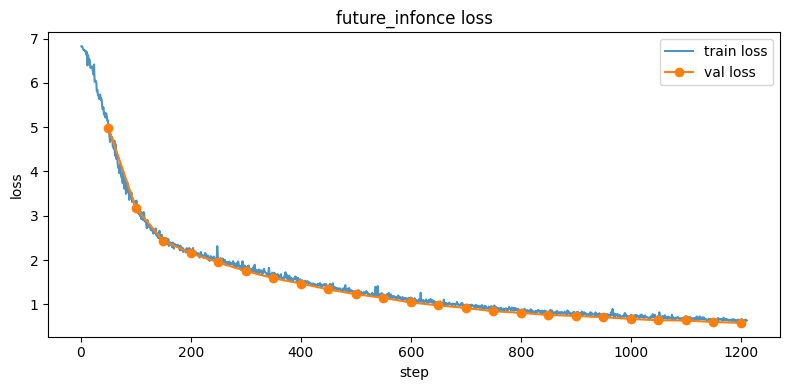

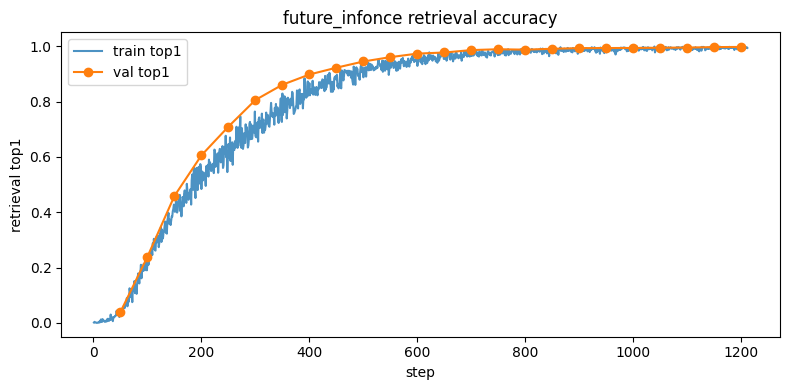

train_start_loss: 6.8280863761901855
train_final_loss: 0.6348381638526917
train_best_loss: 0.6137518286705017 at step 1205
train_final_top1: 0.9937499761581421
val_best_loss: 0.5805529356002808 at step 1200
val_best_top1: 0.997249960899353 at step 1200
plot_loss_path: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260410T153631Z/loss_curve.png
plot_top1_path: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260410T153631Z/retrieval_curve.png


In [8]:
# Plot training curves for the latest SSL run.
if "SSL_RUN_STATE" not in globals():
    raise RuntimeError("Run the SSL training cell or the SSL recovery cell first so SSL_RUN_STATE is defined.")

SSL_PLOT_STATE = plot_ssl_training_history(SSL_RUN_STATE)


## Downstream Probe Workflow

This section is split into five groups:
1. configure and preview the held-out Brain2Text25 probe split
2. recover the default encoder state and optionally inspect saved SSL checkpoints
3. run frozen-encoder comparisons with shared frozen-probe settings
4. run full fine-tuning comparisons with shared notebook `B2` settings
5. inspect saved summaries, diagnostics, and train curves

Only change the shared override dictionaries in the helper cell below when you want to alter probe budgets.
That keeps the SSL vs random-init comparisons aligned.


In [9]:
# Benchmark-lite downstream phoneme probe config.
DOWNSTREAM_PROBE_EXPLICIT_CHECKPOINT_PATH = None
# Example: DOWNSTREAM_PROBE_EXPLICIT_CHECKPOINT_PATH = str((Path(run_dir) / "checkpoints" / "step_000500.pt"))

PROBE_HEAD_LEARNING_RATE = 1e-3
ENCODER_LEARNING_RATE = 1e-4
PROBE_WEIGHT_DECAY = 1e-2

DOWNSTREAM_PROBE_CONFIG = DownstreamProbeConfig(
    enabled=True,
    seed=SEED,
    comparison_mode="ssl_only",
    session_limit=8,
    target_session_count=4,
    adaptation_regime="A",
    probe_batch_size=8,
    probe_budget_seconds=240,
    max_probe_steps=400,
    progress_every_steps=25,
    progress_every_seconds=15.0,
    probe_head_learning_rate=PROBE_HEAD_LEARNING_RATE,
    encoder_learning_rate=ENCODER_LEARNING_RATE,
    weight_decay=PROBE_WEIGHT_DECAY,
    probe_head_type="linear",
    probe_lstm_hidden_size=64,
    probe_conv_hidden_size=128,
    probe_conv_kernel_size=3,
    checkpoint_source="most_recent_valid_then_in_memory",
    explicit_checkpoint_path=DOWNSTREAM_PROBE_EXPLICIT_CHECKPOINT_PATH,
)
DOWNSTREAM_PROBE_SUMMARY_BASENAME = DOWNSTREAM_PROBE_CONFIG.summary_basename

print("DOWNSTREAM_PROBE_CONFIG:", DOWNSTREAM_PROBE_CONFIG)
print(
    "Downstream optimizer config:",
    {
        "probe_head_learning_rate": PROBE_HEAD_LEARNING_RATE,
        "encoder_learning_rate": ENCODER_LEARNING_RATE,
        "weight_decay": PROBE_WEIGHT_DECAY,
    },
)


DOWNSTREAM_PROBE_CONFIG: DownstreamProbeConfig(enabled=True, seed=7, comparison_mode='ssl_only', session_limit=8, target_session_count=4, adaptation_regime='A', probe_batch_size=8, probe_budget_seconds=240, max_probe_steps=400, progress_every_steps=25, progress_every_seconds=15.0, probe_head_learning_rate=0.001, encoder_learning_rate=0.0001, weight_decay=0.01, probe_head_type='linear', probe_lstm_hidden_size=64, probe_conv_hidden_size=128, probe_conv_kernel_size=3, checkpoint_source='most_recent_valid_then_in_memory', explicit_checkpoint_path=None, summary_basename='downstream_probe_summary.json')
Downstream optimizer config: {'probe_head_learning_rate': 0.001, 'encoder_learning_rate': 0.0001, 'weight_decay': 0.01}


In [10]:
# Import and validate benchmark-lite downstream probe helpers from the current repo checkout.
from pathlib import Path

from contrastive_ssl.probe import build_downstream_probe_problem

CANONICAL_B2T25_ROOT = Path(CACHE_ROOT) / "brain2text25"
CANONICAL_B2T25_MANIFEST_PATH = CANONICAL_B2T25_ROOT / "manifest.jsonl"
CANONICAL_B2T25_METADATA_PATH = CANONICAL_B2T25_ROOT / "metadata.json"

if not CANONICAL_B2T25_MANIFEST_PATH.exists() or not CANONICAL_B2T25_METADATA_PATH.exists():
    raise FileNotFoundError(
        "Canonical Brain2Text25 cache manifest / metadata is missing from the mounted cache. "
        f"Expected {CANONICAL_B2T25_MANIFEST_PATH} and {CANONICAL_B2T25_METADATA_PATH}."
    )

downstream_probe_problem_preview = build_downstream_probe_problem(
    cache_root=Path(CACHE_ROOT),
    probe_config=DOWNSTREAM_PROBE_CONFIG,
)
downstream_probe_metadata_preview = downstream_probe_problem_preview["metadata"]

if "phoneme_vocabulary" not in downstream_probe_metadata_preview:
    raise KeyError("Canonical Brain2Text25 metadata is missing 'phoneme_vocabulary'.")

downstream_probe_eligible_entries = downstream_probe_problem_preview["eligible_entries"]
downstream_probe_split_preview = downstream_probe_problem_preview["split"]

print("BENCHMARK_HELPER_SOURCE:", "contrastive_ssl_package")
print("Canonical Brain2Text25 probe assets:")
print(" - root:", CANONICAL_B2T25_ROOT)
print(" - manifest:", CANONICAL_B2T25_MANIFEST_PATH)
print(" - metadata:", CANONICAL_B2T25_METADATA_PATH)
print(" - eligible_sessions:", len(downstream_probe_eligible_entries))
print(" - preview_source_sessions:", [entry.session_base for entry in downstream_probe_split_preview.train])
print(" - preview_target_sessions:", [entry.session_base for entry in downstream_probe_split_preview.val])


BENCHMARK_HELPER_SOURCE: contrastive_ssl_package
Canonical Brain2Text25 probe assets:
 - root: /content/drive/MyDrive/utah_ssl/data/cache_v1/brain2text25
 - manifest: /content/drive/MyDrive/utah_ssl/data/cache_v1/brain2text25/manifest.jsonl
 - metadata: /content/drive/MyDrive/utah_ssl/data/cache_v1/brain2text25/metadata.json
 - eligible_sessions: 45
 - preview_source_sessions: ['t15.2024.07.21', 't15.2024.07.28', 't15.2025.01.10', 't15.2025.01.12']
 - preview_target_sessions: ['t15.2025.03.14', 't15.2025.03.16', 't15.2025.03.30', 't15.2025.04.13']


In [11]:
# Recover the default SSL encoder and prepare reusable downstream probe state.
DOWNSTREAM_PROBE_DEFAULT_STATE = recover_downstream_probe_state(
    probe_config=DOWNSTREAM_PROBE_CONFIG,
    output_root=OUTPUT_ROOT,
    input_dim=FULL_DIM,
    default_checkpoint_config=SSL_TRAINING_CONFIG.checkpoint_config(),
    in_memory_model=SSL_RUN_STATE["model"] if "SSL_RUN_STATE" in globals() else None,
    current_checkpoint_path=Path(checkpoint_path) if "checkpoint_path" in globals() else None,
    current_run_dir=Path(run_dir) if "run_dir" in globals() else None,
)
DOWNSTREAM_PROBE_BASE_RUN_DIR = Path(DOWNSTREAM_PROBE_DEFAULT_STATE["base_run_dir"])
DOWNSTREAM_PROBE_RUN_DIR = DOWNSTREAM_PROBE_BASE_RUN_DIR
DOWNSTREAM_PROBE_CHECKPOINT_PATH = DOWNSTREAM_PROBE_DEFAULT_STATE["checkpoint_path"]
DOWNSTREAM_PROBE_CHECKPOINT_CONFIG = dict(DOWNSTREAM_PROBE_DEFAULT_STATE["checkpoint_config"])
DOWNSTREAM_PROBE_ENCODER_SOURCE = str(DOWNSTREAM_PROBE_DEFAULT_STATE["source"])
DOWNSTREAM_PROBE_ENCODER = DOWNSTREAM_PROBE_DEFAULT_STATE["encoder"]

print("DOWNSTREAM_PROBE_EXPLICIT_CHECKPOINT_PATH:", DOWNSTREAM_PROBE_EXPLICIT_CHECKPOINT_PATH)
print("DOWNSTREAM_PROBE_ENCODER_SOURCE:", DOWNSTREAM_PROBE_ENCODER_SOURCE)
print("DOWNSTREAM_PROBE_BASE_RUN_DIR:", DOWNSTREAM_PROBE_BASE_RUN_DIR)
print("DOWNSTREAM_PROBE_CHECKPOINT_PATH:", DOWNSTREAM_PROBE_CHECKPOINT_PATH)
print("DOWNSTREAM_PROBE_CHECKPOINT_SELECTION:", DOWNSTREAM_PROBE_CONFIG.checkpoint_source)
print("DOWNSTREAM_PROBE_ENCODER:", DOWNSTREAM_PROBE_ENCODER)


DOWNSTREAM_PROBE_EXPLICIT_CHECKPOINT_PATH: None
DOWNSTREAM_PROBE_ENCODER_SOURCE: checkpoint
DOWNSTREAM_PROBE_BASE_RUN_DIR: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260406T155149Z
DOWNSTREAM_PROBE_CHECKPOINT_PATH: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260406T155149Z/checkpoint_final.pt
DOWNSTREAM_PROBE_CHECKPOINT_SELECTION: most_recent_valid_then_in_memory
DOWNSTREAM_PROBE_ENCODER: NotebookProbeEncoderAdapter(
  (encoder): S5ContrastiveEncoder(
    (proj): Linear(in_features=1536, out_features=256, bias=True)
    (post_proj_norm): RMSNorm()
    (backbone): S5SequenceBackbone(
      (blocks): ModuleList(
        (0-1): 2 x S5Block(
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (ssm): DiagonalS5SSM(
            (D): Linear(in_features=256, out_features=256, bias=False)
          )
          (dropout1): Dropout(p=0.1, inplace=False)
 

In [24]:
# List saved SSL checkpoints for the current run so probes can target an intermediate step.
import pandas as pd

CHECKPOINT_LIST_RUN_DIR = Path(run_dir) if "run_dir" in globals() else DOWNSTREAM_PROBE_BASE_RUN_DIR
AVAILABLE_SSL_CHECKPOINTS = list_ssl_checkpoints(CHECKPOINT_LIST_RUN_DIR)
AVAILABLE_SSL_CHECKPOINTS_DF = pd.DataFrame(AVAILABLE_SSL_CHECKPOINTS)

display(AVAILABLE_SSL_CHECKPOINTS_DF)
print("CHECKPOINT_LIST_RUN_DIR:", CHECKPOINT_LIST_RUN_DIR)
print(
    "To probe an intermediate checkpoint, set DOWNSTREAM_PROBE_EXPLICIT_CHECKPOINT_PATH to one of the paths above, "
    "then rerun the downstream probe config and recovery cells."
)


,path,name,kind,mtime_seconds,step,best_score,best_step,checkpoint_kind
0,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,step_000100.pt,step,1.775835e+09,100,3.174075,100,step
1,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,step_000200.pt,step,1.775835e+09,200,2.157105,200,step
2,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,step_000300.pt,step,1.775835e+09,300,1.751412,300,step
3,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,step_000400.pt,step,1.775836e+09,400,1.469188,400,step
4,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,step_000500.pt,step,1.775836e+09,500,1.228911,500,step
5,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,step_000600.pt,step,1.775836e+09,600,1.042105,600,step
6,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,step_000700.pt,step,1.775836e+09,700,0.918045,700,step
7,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,step_000800.pt,step,1.775836e+09,800,0.807105,800,step
8,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,step_000900.pt,step,1.775836e+09,900,0.738269,900,step
9,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,step_001000.pt,step,1.775836e+09,1000,0.670008,1000,step


CHECKPOINT_LIST_RUN_DIR: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260410T153631Z
To probe an intermediate checkpoint, set DOWNSTREAM_PROBE_EXPLICIT_CHECKPOINT_PATH to one of the paths above, then rerun the downstream probe config and recovery cells.


,representation,horizon,mean_top1,mean_loss,mean_local_margin,mean_local_win_rate,mean_positive_pairs,mean_candidate_count
0,checkpoint_heads,1,0.740779,5.985568,0.028867,0.740779,976.0,976.0
1,encoder_hidden,1,0.002561,6.377429,-0.280400,0.000000,976.0,976.0
2,raw_tokens,1,0.000256,6.822897,-0.934251,0.000000,976.0,976.0
3,checkpoint_heads,3,0.288400,5.977435,-0.025299,0.256621,944.0,944.0
4,encoder_hidden,3,0.006621,6.491683,-0.175095,0.001589,944.0,944.0
5,raw_tokens,3,0.002648,6.773888,-0.035590,0.252648,944.0,944.0


SSL_RETRIEVAL_DIAGNOSTIC_CHECKPOINT_PATH: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260406T155149Z/checkpoint_final.pt
SSL_RETRIEVAL_DIAGNOSTIC_SPLIT: val
SSL_RETRIEVAL_DIAGNOSTIC_HORIZONS: (1, 3)
SSL retrieval diagnostic config: {'patch_size': 3, 'patch_stride': 1, 'future_horizons': [1, 3], 'normalize_impl_version': 'segment_prefix_v1'}


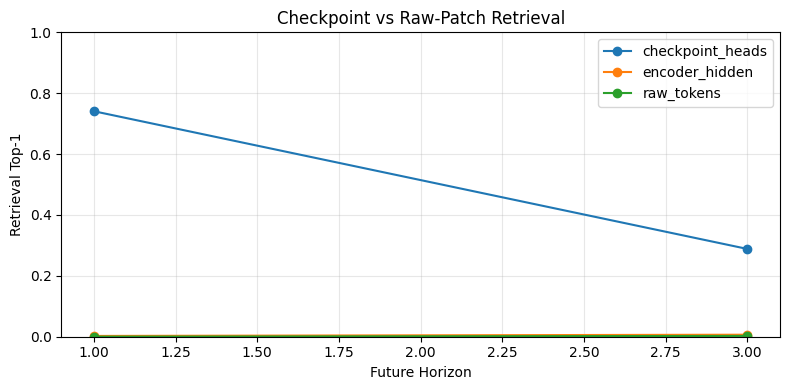

In [25]:
# Compare checkpoint retrieval against raw patch retrieval on the same SSL batches.
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F

from contrastive_ssl.model import ContrastiveSSLModel

SSL_RETRIEVAL_DIAGNOSTIC_BATCHES = 4
SSL_RETRIEVAL_DIAGNOSTIC_BATCH_SIZE = 16
SSL_RETRIEVAL_DIAGNOSTIC_SPLIT = "val" if CACHE_CONTEXT.has_val_datasets else "train"
SSL_RETRIEVAL_DIAGNOSTIC_CHECKPOINT_PATH = Path(
    DOWNSTREAM_PROBE_CHECKPOINT_PATH
    if DOWNSTREAM_PROBE_CHECKPOINT_PATH is not None
    else checkpoint_path
)

if not SSL_RETRIEVAL_DIAGNOSTIC_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint path does not exist: {SSL_RETRIEVAL_DIAGNOSTIC_CHECKPOINT_PATH}"
    )

ssl_diag_payload = torch.load(SSL_RETRIEVAL_DIAGNOSTIC_CHECKPOINT_PATH, map_location="cpu")
ssl_diag_config = dict(ssl_diag_payload.get("config", {}))
if not ssl_diag_config:
    ssl_diag_config_path = SSL_RETRIEVAL_DIAGNOSTIC_CHECKPOINT_PATH.parent / "config.json"
    if ssl_diag_config_path.exists():
        ssl_diag_config = json.loads(ssl_diag_config_path.read_text())

SSL_RETRIEVAL_DIAGNOSTIC_HORIZONS = tuple(
    int(value)
    for value in ssl_diag_config.get(
        "future_horizons",
        config.get("future_horizons", FUTURE_HORIZONS) if isinstance(config, dict) else FUTURE_HORIZONS,
    )
)

ssl_diag_model = ContrastiveSSLModel(
    input_dim=FULL_DIM,
    hidden_size=int(ssl_diag_config["hidden_size"]),
    s5_state_size=int(ssl_diag_config["s5_state_size"]),
    num_layers=int(ssl_diag_config["num_layers"]),
    dropout=float(ssl_diag_config["dropout"]),
    patch_size=int(ssl_diag_config["patch_size"]),
    patch_stride=int(ssl_diag_config["patch_stride"]),
    post_proj_norm=str(ssl_diag_config.get("post_proj_norm", "identity")),
).to(DEVICE)
ssl_diag_model.load_state_dict(ssl_diag_payload["model_state"])
ssl_diag_model.eval()

ssl_diag_sampler = build_segment_sampler(
    CACHE_CONTEXT,
    SSL_RETRIEVAL_DIAGNOSTIC_SPLIT,
    batch_size=SSL_RETRIEVAL_DIAGNOSTIC_BATCH_SIZE,
    seed=SEED + 404,
    segment_bins=int(ssl_diag_config.get("segment_bins", SEGMENT_BINS)),
    dataset_weight_alpha=float(ssl_diag_config.get("dataset_weight_alpha", DATASET_WEIGHT_ALPHA)),
    examples_per_shard=int(ssl_diag_config.get("examples_per_shard", EXAMPLES_PER_SHARD)),
)


def compute_future_retrieval_rows(anchor_reps, future_reps, token_lengths, horizons, representation_name, batch_index):
    rows = []
    anchor_reps = F.normalize(anchor_reps, dim=-1)
    future_reps = F.normalize(future_reps, dim=-1)

    for horizon in horizons:
        q_list = []
        k_list = []
        local_margins = []
        local_win_flags = []

        for sample_idx, length in enumerate(token_lengths.tolist()):
            usable = int(length) - int(horizon)
            if usable <= 0:
                continue

            q_sample = anchor_reps[sample_idx, :usable]
            k_sample = future_reps[sample_idx, horizon:length]
            q_list.append(q_sample)
            k_list.append(k_sample)

            local_offsets = (-2, -1, 1, 2)
            for time_idx in range(usable):
                true_target = time_idx + int(horizon)
                true_sim = float(torch.dot(anchor_reps[sample_idx, time_idx], future_reps[sample_idx, true_target]).item())
                neighbor_sims = []
                for offset in local_offsets:
                    alt_target = true_target + int(offset)
                    if alt_target < 0 or alt_target >= int(length):
                        continue
                    neighbor_sims.append(
                        float(torch.dot(anchor_reps[sample_idx, time_idx], future_reps[sample_idx, alt_target]).item())
                    )
                if neighbor_sims:
                    best_neighbor = max(neighbor_sims)
                    local_margins.append(true_sim - best_neighbor)
                    local_win_flags.append(float(true_sim > best_neighbor))

        if not q_list:
            continue

        q = torch.cat(q_list, dim=0)
        k = torch.cat(k_list, dim=0)
        logits = q @ k.T
        labels = torch.arange(q.shape[0], device=logits.device)
        rows.append(
            {
                "batch_index": int(batch_index),
                "representation": str(representation_name),
                "horizon": int(horizon),
                "positive_pairs": int(q.shape[0]),
                "candidate_count": int(k.shape[0]),
                "top1": float((logits.argmax(dim=1) == labels).float().mean().item()),
                "loss": float(F.cross_entropy(logits, labels).item()),
                "local_margin_mean": (
                    float(sum(local_margins) / len(local_margins)) if local_margins else None
                ),
                "local_win_rate": (
                    float(sum(local_win_flags) / len(local_win_flags)) if local_win_flags else None
                ),
            }
        )
    return rows


ssl_diag_rows = []
with torch.no_grad():
    for batch_index in range(SSL_RETRIEVAL_DIAGNOSTIC_BATCHES):
        batch = ssl_diag_sampler.sample_batch()
        outputs = ssl_diag_model.encode_sequence(
            batch["x"].to(DEVICE),
            batch["lengths"].to(DEVICE),
        )
        token_lengths = outputs["token_lengths"]
        representation_map = {
            "raw_tokens": (outputs["tokens"], outputs["tokens"]),
            "encoder_hidden": (outputs["hidden"], outputs["hidden"]),
            "checkpoint_heads": (
                ssl_diag_model.anchor_head(outputs["hidden"]),
                ssl_diag_model.future_head(outputs["hidden"]),
            ),
        }
        for representation_name, (anchor_reps, future_reps) in representation_map.items():
            ssl_diag_rows.extend(
                compute_future_retrieval_rows(
                    anchor_reps=anchor_reps,
                    future_reps=future_reps,
                    token_lengths=token_lengths,
                    horizons=SSL_RETRIEVAL_DIAGNOSTIC_HORIZONS,
                    representation_name=representation_name,
                    batch_index=batch_index,
                )
            )

SSL_RETRIEVAL_DIAGNOSTIC_DF = pd.DataFrame(ssl_diag_rows)
SSL_RETRIEVAL_DIAGNOSTIC_SUMMARY = (
    SSL_RETRIEVAL_DIAGNOSTIC_DF.groupby(["representation", "horizon"], as_index=False)
    .agg(
        mean_top1=("top1", "mean"),
        mean_loss=("loss", "mean"),
        mean_local_margin=("local_margin_mean", "mean"),
        mean_local_win_rate=("local_win_rate", "mean"),
        mean_positive_pairs=("positive_pairs", "mean"),
        mean_candidate_count=("candidate_count", "mean"),
    )
    .sort_values(["horizon", "representation"])
    .reset_index(drop=True)
)

display(SSL_RETRIEVAL_DIAGNOSTIC_SUMMARY)
print("SSL_RETRIEVAL_DIAGNOSTIC_CHECKPOINT_PATH:", SSL_RETRIEVAL_DIAGNOSTIC_CHECKPOINT_PATH)
print("SSL_RETRIEVAL_DIAGNOSTIC_SPLIT:", SSL_RETRIEVAL_DIAGNOSTIC_SPLIT)
print("SSL_RETRIEVAL_DIAGNOSTIC_HORIZONS:", SSL_RETRIEVAL_DIAGNOSTIC_HORIZONS)
print(
    "SSL retrieval diagnostic config:",
    {
        "patch_size": ssl_diag_config.get("patch_size"),
        "patch_stride": ssl_diag_config.get("patch_stride"),
        "future_horizons": ssl_diag_config.get("future_horizons"),
        "normalize_impl_version": ssl_diag_config.get("normalize_impl_version"),
    },
)

plt.figure(figsize=(8, 4))
for representation_name, group in SSL_RETRIEVAL_DIAGNOSTIC_SUMMARY.groupby("representation"):
    plt.plot(group["horizon"], group["mean_top1"], marker="o", label=representation_name)
plt.xlabel("Future Horizon")
plt.ylabel("Retrieval Top-1")
plt.title("Checkpoint vs Raw-Patch Retrieval")
plt.ylim(0.0, 1.0)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
# Shared downstream experiment helpers.
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

FROZEN_LINEAR_PROBE_OVERRIDES = {
    "probe_head_type": "linear",
}

QUICK_CONV1D_PROBE_OVERRIDES = {
    "probe_head_type": "conv1d",
    "probe_conv_hidden_size": DOWNSTREAM_PROBE_DEFAULT_STATE["encoder"].hidden_size,
    "probe_conv_kernel_size": 3,
    "probe_budget_seconds": 120,
    "max_probe_steps": 50,
}

B2_LINEAR_PROBE_OVERRIDES = {
    "probe_head_type": "linear",
    "probe_head_learning_rate": PROBE_HEAD_LEARNING_RATE,
    "encoder_learning_rate": ENCODER_LEARNING_RATE,
    "weight_decay": PROBE_WEIGHT_DECAY,
    "probe_budget_seconds": 600,
    "max_probe_steps": 800,
}

SUMMARY_DISPLAY_COLUMNS = [
    "model_variant",
    "train_encoder",
    "probe_head_type",
    "probe_head_num_parameters",
    "probe_head_learning_rate",
    "encoder_learning_rate",
    "target_session_ids",
    "target_train_examples",
    "target_val_examples",
    "val_ctc_bpphone",
    "val_phoneme_error_rate",
    "most_common_prediction",
    "most_common_prediction_rate",
    "most_common_false_prediction",
    "most_common_false_prediction_rate",
    "top_substitution_pair",
    "probe_steps",
    "probe_elapsed_seconds",
]

COMPARISON_DISPLAY_COLUMNS = [
    "model_variant",
    "train_encoder",
    "probe_head_type",
    "probe_head_learning_rate",
    "encoder_learning_rate",
    "val_ctc_bpphone",
    "val_phoneme_error_rate",
    "most_common_prediction",
    "most_common_prediction_rate",
    "most_common_false_prediction",
    "most_common_false_prediction_rate",
    "top_substitution_pair",
    "probe_steps",
    "probe_elapsed_seconds",
]


def build_notebook_random_probe_state(*, seed_offset: int = 0):
    return build_random_init_probe_state(
        reference_config=DOWNSTREAM_PROBE_DEFAULT_STATE["checkpoint_config"],
        input_dim=FULL_DIM,
        seed=SEED + int(seed_offset),
        base_run_dir=DOWNSTREAM_PROBE_BASE_RUN_DIR,
    )


def run_notebook_probe(
    summary_name: str,
    *,
    probe_state: dict,
    variant_prefix: str,
    artifact_prefix: str,
    train_encoder: bool,
    probe_overrides: dict | None = None,
    comparison_mode: str | None = None,
) -> dict:
    summary = run_downstream_probe(
        probe_state=probe_state,
        probe_config=DOWNSTREAM_PROBE_CONFIG,
        cache_root=CACHE_ROOT,
        device=DEVICE,
        variant_prefix=variant_prefix,
        artifact_prefix=artifact_prefix,
        train_encoder=train_encoder,
        probe_overrides=probe_overrides,
        comparison_mode=comparison_mode,
    )
    globals()[summary_name] = summary
    display(pd.DataFrame([summary])[SUMMARY_DISPLAY_COLUMNS])
    print(f"{summary_name.lower()}_summary_path:", Path(summary["summary_path"]))
    print(f"{summary_name.lower()}_progress_path:", Path(summary["progress_log_path"]))
    if summary.get("alignment_stats_path") is not None:
        print(f"{summary_name.lower()}_alignment_stats_path:", Path(summary["alignment_stats_path"]))
    return summary


def display_probe_comparison(summary_names: list[str], *, columns: list[str] | None = None) -> pd.DataFrame:
    rows = [globals()[name] for name in summary_names if name in globals()]
    if not rows:
        raise ValueError("None of the requested summary variables are defined in the current kernel.")
    frame = pd.DataFrame(rows)
    display(frame[columns or COMPARISON_DISPLAY_COLUMNS])
    return frame


def print_top_items(items, *, max_items: int = 8) -> None:
    if not items:
        print("  <none>")
        return
    for item in items[:max_items]:
        label = item.get("symbol", item.get("id"))
        print(f"  - {label} count={item['count']} rate={item['rate']:.3f}")


def print_substitution_items(items, *, max_items: int = 8) -> None:
    if not items:
        print("  <none>")
        return
    for item in items[:max_items]:
        print(
            f"  - {item['reference_symbol']} -> {item['predicted_symbol']} "
            f"count={item['count']} rate={item['rate']:.3f}"
        )


def print_alignment_diagnostics_from_summary(summary_name: str, *, max_items: int = 8) -> dict:
    if summary_name not in globals():
        raise NameError(f"{summary_name} is not defined in the current kernel.")
    summary = globals()[summary_name]
    stats_path = Path(summary["alignment_stats_path"])
    stats = json.loads(stats_path.read_text())

    print(f"\ndiagnostics_for: {summary_name.lower()}")
    print(" alignment_stats_path:", stats_path)
    print(" total_reference_tokens:", stats["total_reference_tokens"])
    print(" total_predicted_tokens:", stats["total_predicted_tokens"])
    print(" total_edit_distance:", stats["total_edit_distance"])
    print(" total_insertions:", stats["total_insertions"])
    print(" total_deletions:", stats["total_deletions"])
    print(" total_substitutions:", stats["total_substitutions"])

    most_common_prediction = stats.get("most_common_prediction")
    if most_common_prediction is not None:
        print(
            " most_common_prediction:",
            most_common_prediction["symbol"],
            f"count={most_common_prediction['count']} rate={most_common_prediction['rate']:.3f}",
        )

    most_common_false_prediction = stats.get("most_common_false_prediction")
    if most_common_false_prediction is not None:
        print(
            " most_common_false_prediction:",
            most_common_false_prediction["symbol"],
            f"count={most_common_false_prediction['count']} rate={most_common_false_prediction['rate']:.3f}",
        )

    top_substitution_pair = stats.get("top_substitution_pair")
    if top_substitution_pair is not None:
        print(
            " top_substitution_pair:",
            f"{top_substitution_pair['reference_symbol']} -> {top_substitution_pair['predicted_symbol']}",
            f"count={top_substitution_pair['count']} rate={top_substitution_pair['rate']:.3f}",
        )

    print(" prediction_histogram_top:")
    print_top_items(stats.get("prediction_histogram_top", []), max_items=max_items)

    print(" false_prediction_histogram_top:")
    print_top_items(stats.get("false_prediction_histogram_top", []), max_items=max_items)

    print(" insertion_histogram_top:")
    print_top_items(stats.get("insertion_histogram_top", []), max_items=max_items)

    print(" deletion_histogram_top:")
    print_top_items(stats.get("deletion_histogram_top", []), max_items=max_items)

    print(" substitution_histogram_top:")
    print_substitution_items(stats.get("substitution_histogram_top", []), max_items=max_items)
    return stats


def load_probe_progress(summary_name: str) -> pd.DataFrame:
    if summary_name not in globals():
        raise NameError(f"{summary_name} is not defined in the current kernel.")
    progress_path = Path(globals()[summary_name]["progress_log_path"])
    rows = [json.loads(line) for line in progress_path.read_text().splitlines() if line.strip()]
    return pd.DataFrame(rows)


def plot_probe_train_curves(summary_names: list[str]) -> None:
    plt.figure(figsize=(7, 4))
    plotted = False
    for summary_name in summary_names:
        if summary_name not in globals():
            continue
        frame = load_probe_progress(summary_name)
        train_rows = frame[frame["event"] == "probe_train_report"].copy()
        if train_rows.empty:
            continue
        plt.plot(train_rows["step"], train_rows["train_ctc_bpphone"], label=summary_name)
        plotted = True
    if not plotted:
        raise ValueError("None of the requested summaries include probe_train_report rows.")
    plt.xlabel("Probe Step")
    plt.ylabel("Train CTC Bits / Phoneme")
    plt.title("Downstream Probe Train Curves")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


print("FROZEN_LINEAR_PROBE_OVERRIDES:", FROZEN_LINEAR_PROBE_OVERRIDES)
print("QUICK_CONV1D_PROBE_OVERRIDES:", QUICK_CONV1D_PROBE_OVERRIDES)
print("B2_LINEAR_PROBE_OVERRIDES:", B2_LINEAR_PROBE_OVERRIDES)


FROZEN_LINEAR_PROBE_OVERRIDES: {'probe_head_type': 'linear'}
QUICK_CONV1D_PROBE_OVERRIDES: {'probe_head_type': 'conv1d', 'probe_conv_hidden_size': 256, 'probe_conv_kernel_size': 3, 'probe_budget_seconds': 120, 'max_probe_steps': 50}
B2_LINEAR_PROBE_OVERRIDES: {'probe_head_type': 'linear', 'probe_head_learning_rate': 0.001, 'encoder_learning_rate': 0.0001, 'weight_decay': 0.01, 'probe_budget_seconds': 600, 'max_probe_steps': 800}


### Frozen-Encoder Comparisons

These cells keep the encoder frozen.
The two linear cells below are the main apples-to-apples frozen comparison.
The conv1d cell is a quick stronger-head diagnostic with its own smaller budget.


In [ ]:
# Frozen SSL checkpoint + linear head.
SSL_PROBE_SUMMARY = run_notebook_probe(
    "SSL_PROBE_SUMMARY",
    probe_state=DOWNSTREAM_PROBE_DEFAULT_STATE,
    variant_prefix="ssl_checkpoint",
    artifact_prefix="ssl_probe_pool4",
    train_encoder=False,
    probe_overrides=FROZEN_LINEAR_PROBE_OVERRIDES,
    comparison_mode="ssl_only_pool4",
)


KeyboardInterrupt: 

In [ ]:
# Frozen random-init baseline + linear head.
RANDOM_INIT_LINEAR_PROBE_STATE = build_notebook_random_probe_state()
RANDOM_INIT_LINEAR_PROBE_SUMMARY = run_notebook_probe(
    "RANDOM_INIT_LINEAR_PROBE_SUMMARY",
    probe_state=RANDOM_INIT_LINEAR_PROBE_STATE,
    variant_prefix="random_init",
    artifact_prefix="random_init_pool4",
    train_encoder=False,
    probe_overrides=FROZEN_LINEAR_PROBE_OVERRIDES,
    comparison_mode="random_init_pool4",
)


In [ ]:
# Optional quick stronger-head diagnostic on the frozen SSL encoder.
QUICK_CONV1D_SUMMARY = run_notebook_probe(
    "QUICK_CONV1D_SUMMARY",
    probe_state=DOWNSTREAM_PROBE_DEFAULT_STATE,
    variant_prefix="ssl_checkpoint",
    artifact_prefix="ssl_probe_quick_pool4",
    train_encoder=False,
    probe_overrides=QUICK_CONV1D_PROBE_OVERRIDES,
    comparison_mode="ssl_only_conv1d_pool4_quick",
)


In [ ]:
# Compare whichever frozen-probe summaries are currently available.
display_probe_comparison([
    "SSL_PROBE_SUMMARY",
    "RANDOM_INIT_LINEAR_PROBE_SUMMARY",
    "QUICK_CONV1D_SUMMARY",
])


### Full Fine-Tuning Comparisons

These cells run the notebook's simplified `B2` path: fine-tune the encoder and linear head together.
Both cells below use the same shared `B2_LINEAR_PROBE_OVERRIDES` dictionary on purpose.


In [ ]:
# SSL-initialized notebook B2 run.
SSL_B2_SUMMARY = run_notebook_probe(
    "SSL_B2_SUMMARY",
    probe_state=DOWNSTREAM_PROBE_DEFAULT_STATE,
    variant_prefix="ssl_checkpoint_b2",
    artifact_prefix="ssl_probe_b2_pool4",
    train_encoder=True,
    probe_overrides=B2_LINEAR_PROBE_OVERRIDES,
    comparison_mode="ssl_b2_pool4",
)


In [ ]:
# Random-init notebook B2 baseline with the exact same budget as SSL_B2.
RANDOM_INIT_B2_STATE = build_notebook_random_probe_state()
RANDOM_INIT_B2_SUMMARY = run_notebook_probe(
    "RANDOM_INIT_B2_SUMMARY",
    probe_state=RANDOM_INIT_B2_STATE,
    variant_prefix="random_init_b2",
    artifact_prefix="random_init_b2_pool4",
    train_encoder=True,
    probe_overrides=B2_LINEAR_PROBE_OVERRIDES,
    comparison_mode="random_init_b2_pool4",
)


In [ ]:
# Compare whichever notebook B2 summaries are currently available.
display_probe_comparison([
    "SSL_B2_SUMMARY",
    "RANDOM_INIT_B2_SUMMARY",
])


### Diagnostics And Curves

Set the summary names in the cells below to focus on the runs you want to inspect.
The default diagnostic cell targets the notebook `B2` pair because that is the easiest comparison to misread.


In [ ]:
# Print compact alignment diagnostics for the summaries listed here.
DIAGNOSTIC_SUMMARY_NAMES = [
    "SSL_B2_SUMMARY",
    "RANDOM_INIT_B2_SUMMARY",
]

display_probe_comparison(DIAGNOSTIC_SUMMARY_NAMES)
for summary_name in DIAGNOSTIC_SUMMARY_NAMES:
    if summary_name in globals():
        print_alignment_diagnostics_from_summary(summary_name)


ValueError: None of the requested summary variables are defined in the current kernel.

In [ ]:
# Plot train curves for any summaries that have progress logs in the current kernel.
PLOT_SUMMARY_NAMES = [
    "SSL_PROBE_SUMMARY",
    "RANDOM_INIT_LINEAR_PROBE_SUMMARY",
    "QUICK_CONV1D_SUMMARY",
    "SSL_B2_SUMMARY",
    "RANDOM_INIT_B2_SUMMARY",
]

plot_probe_train_curves(PLOT_SUMMARY_NAMES)


ValueError: None of the requested summaries include probe_train_report rows.

<Figure size 700x400 with 0 Axes>

,step,elapsed_seconds,train_ctc_bpphone
31,155,460.673,4.491081
32,161,478.176,3.905964
33,166,494.021,4.229651
34,171,509.163,3.981184
35,175,521.222,3.941682
36,181,536.682,4.491632
37,187,554.350,4.453775
38,193,572.380,4.732830
39,199,589.166,4.212487
40,200,592.183,4.807109


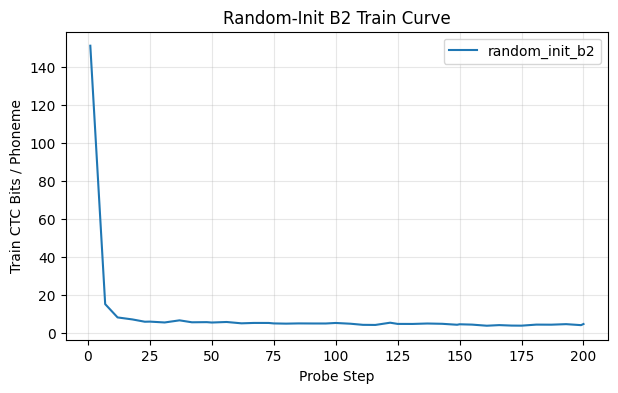

random_init_b2_final_val_ctc_bpphone: 5.451282567055353
random_init_b2_final_val_phoneme_error_rate: 0.7937562271670542


In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

random_b2_progress_path = Path(
    "/content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/"
    "colab_s5_future_infonce_seg64_20260406T155149Z/"
    "random_init_b2_pool4_linear_probe/progress.jsonl"
)

rows = [json.loads(line) for line in random_b2_progress_path.read_text().splitlines() if line.strip()]
df = pd.DataFrame(rows)

train_df = df[df["event"] == "probe_train_report"].copy()
final_df = df[df["event"] == "probe_session_complete"].copy()

display(train_df[["step", "elapsed_seconds", "train_ctc_bpphone"]].tail(10))

plt.figure(figsize=(7, 4))
plt.plot(train_df["step"], train_df["train_ctc_bpphone"], label="random_init_b2")
plt.xlabel("Probe Step")
plt.ylabel("Train CTC Bits / Phoneme")
plt.title("Random-Init B2 Train Curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

if not final_df.empty:
    final_row = final_df.iloc[-1]
    print("random_init_b2_final_val_ctc_bpphone:", final_row["val_ctc_bpphone"])
    print("random_init_b2_final_val_phoneme_error_rate:", final_row["val_phoneme_error_rate"])


In [ ]:
import matplotlib.pyplot as plt

def mean_cosine_vs_delta(a_source, b_source, token_lengths, max_delta=8):
    rows = []
    for delta in range(max_delta + 1):
        vals = []
        for seq_idx, length in enumerate(token_lengths.tolist()):
            length = int(length)
            usable = length - delta
            if usable <= 0:
                continue
            a = F.normalize(a_source[seq_idx, :usable], dim=-1)
            b = F.normalize(b_source[seq_idx, delta:length], dim=-1)
            vals.append((a * b).sum(dim=-1).detach().cpu())
        if vals:
            rows.append({
                "delta": delta,
                "mean_cosine": torch.cat(vals).mean().item(),
            })
    return pd.DataFrame(rows)

raw_delta_df = mean_cosine_vs_delta(tokens, tokens, token_lengths, max_delta=8)
proj_delta_df = mean_cosine_vs_delta(proj_tokens, proj_tokens, token_lengths, max_delta=8)
ssl_delta_df = mean_cosine_vs_delta(anchor_z, future_z, token_lengths, max_delta=8)

plt.figure(figsize=(7, 4))
plt.plot(raw_delta_df["delta"], raw_delta_df["mean_cosine"], marker="o", label="raw patches")
plt.plot(proj_delta_df["delta"], proj_delta_df["mean_cosine"], marker="o", label="projected patches")
plt.plot(ssl_delta_df["delta"], ssl_delta_df["mean_cosine"], marker="o", label="ssl anchor/future")
plt.xlabel("Delta (token steps)")
plt.ylabel("Mean cosine similarity")
plt.title("Similarity vs temporal offset")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


NameError: name 'tokens' is not defined